Load df and generate new features

In [1]:
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import sys
sys.path.append("..")

df = pd.read_pickle("../data/embeddings_v3.pkl")

In [2]:
from python_editor.feature_generation_v2 import generate_features, FEATURES

df = df.drop(columns=["NUM_CHARS", "pylint_text", "executable_code"])

features = df.progress_apply(generate_features, axis=1, result_type="expand")
df_features = df.join(features)
df_features.head()

  0%|          | 0/3479 [00:00<?, ?it/s]

100%|██████████| 3479/3479 [00:11<00:00, 295.82it/s]


,text,repo_name,path,license,pylint_score,embedding,developer,characters,code_compactness,line_length_std,...,bad_name_ratio,comment_ratio,has_docstring,variable_density,func_density,too_many_args_ratio,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports_ratio
0,"""""""\nOutlier Detection using Tukeys Filter Cla...",trademob/anna-molly,lib/plugins/tukeys_filter.py,mit,7.634409,"[-0.38697323, 0.24379842, 0.23942713, -0.03379...",trademob,5255.0,0.846154,22.502240,...,0.000000,0.036364,1.0,0.200000,0.045455,0.0,0.009091,5.000000,0.000000,0.142857
1,# Copyright (c) 2018 PaddlePaddle Authors. A...,PaddlePaddle/Paddle,python/paddle/fluid/tests/unittests/xpu/test_r...,apache-2.0,7.037037,"[-0.40957466, 0.19089544, 0.26356944, 0.009104...",PaddlePaddle,6221.0,0.816667,17.948275,...,0.114754,0.115646,0.0,0.020408,0.156463,0.0,0.074830,2.090909,0.000000,0.111111
2,# -*- coding: utf-8 -*-\nfrom __future__ impor...,marevol/gym-starter-kit-example,pong/__init__.py,apache-2.0,8.000000,"[-0.2769219, 0.08974697, 0.25448853, -0.019443...",marevol,240.0,0.666667,19.906029,...,1.000000,0.166667,0.0,0.333333,0.000000,0.0,0.000000,0.000000,0.000000,0.666667
3,import re\n\nfrom tornado.escape import xhtml_...,JmPotato/College,handlers/utils.py,mit,7.872340,"[-0.3845056, 0.09546796, 0.2581636, 0.05189531...",JmPotato,2237.0,0.805970,17.442046,...,0.108108,0.000000,0.0,0.240741,0.111111,0.0,0.000000,0.000000,0.166667,0.250000
4,from tests import PMGTestCase\nfrom pmg.models...,Code4SA/pmg-cms-2,tests/unit/test_attendance.py,apache-2.0,8.358209,"[-0.35930574, 0.17806531, 0.24545142, -0.08270...",Code4SA,6441.0,0.893617,22.173135,...,0.025641,0.011905,0.0,0.136905,0.029762,0.0,0.005952,5.000000,0.333333,0.000000


Split data

In [3]:
from python_editor.data_processing import split_by_developer

train, test = split_by_developer(df_features, test_size=0.3, random_state=0)

Looking at skewness of generated features we see some heavily skewed features like avg_func_lines and line_length_std. Transformation will be helpful

In [4]:
num_features = FEATURES.copy()
num_features.append("pylint_score")
num_features.remove("has_docstring")

skewness = train[num_features].skew().sort_values(ascending=False)
skewness

line_length_std               11.272151
too_many_args_ratio            8.391177
cyclomatic_complexity          6.824315
long_line_ratio                6.002273
avg_class_methods              4.172068
characters                     4.096285
class_density                  3.856268
variable_density               3.088914
bad_name_ratio                 2.769856
unused_imports_ratio           2.312144
comment_ratio                  2.131161
func_density                   1.758792
func_class_docstring_ratio     1.470877
code_compactness              -0.467554
pylint_score                  -0.575629
dtype: float64

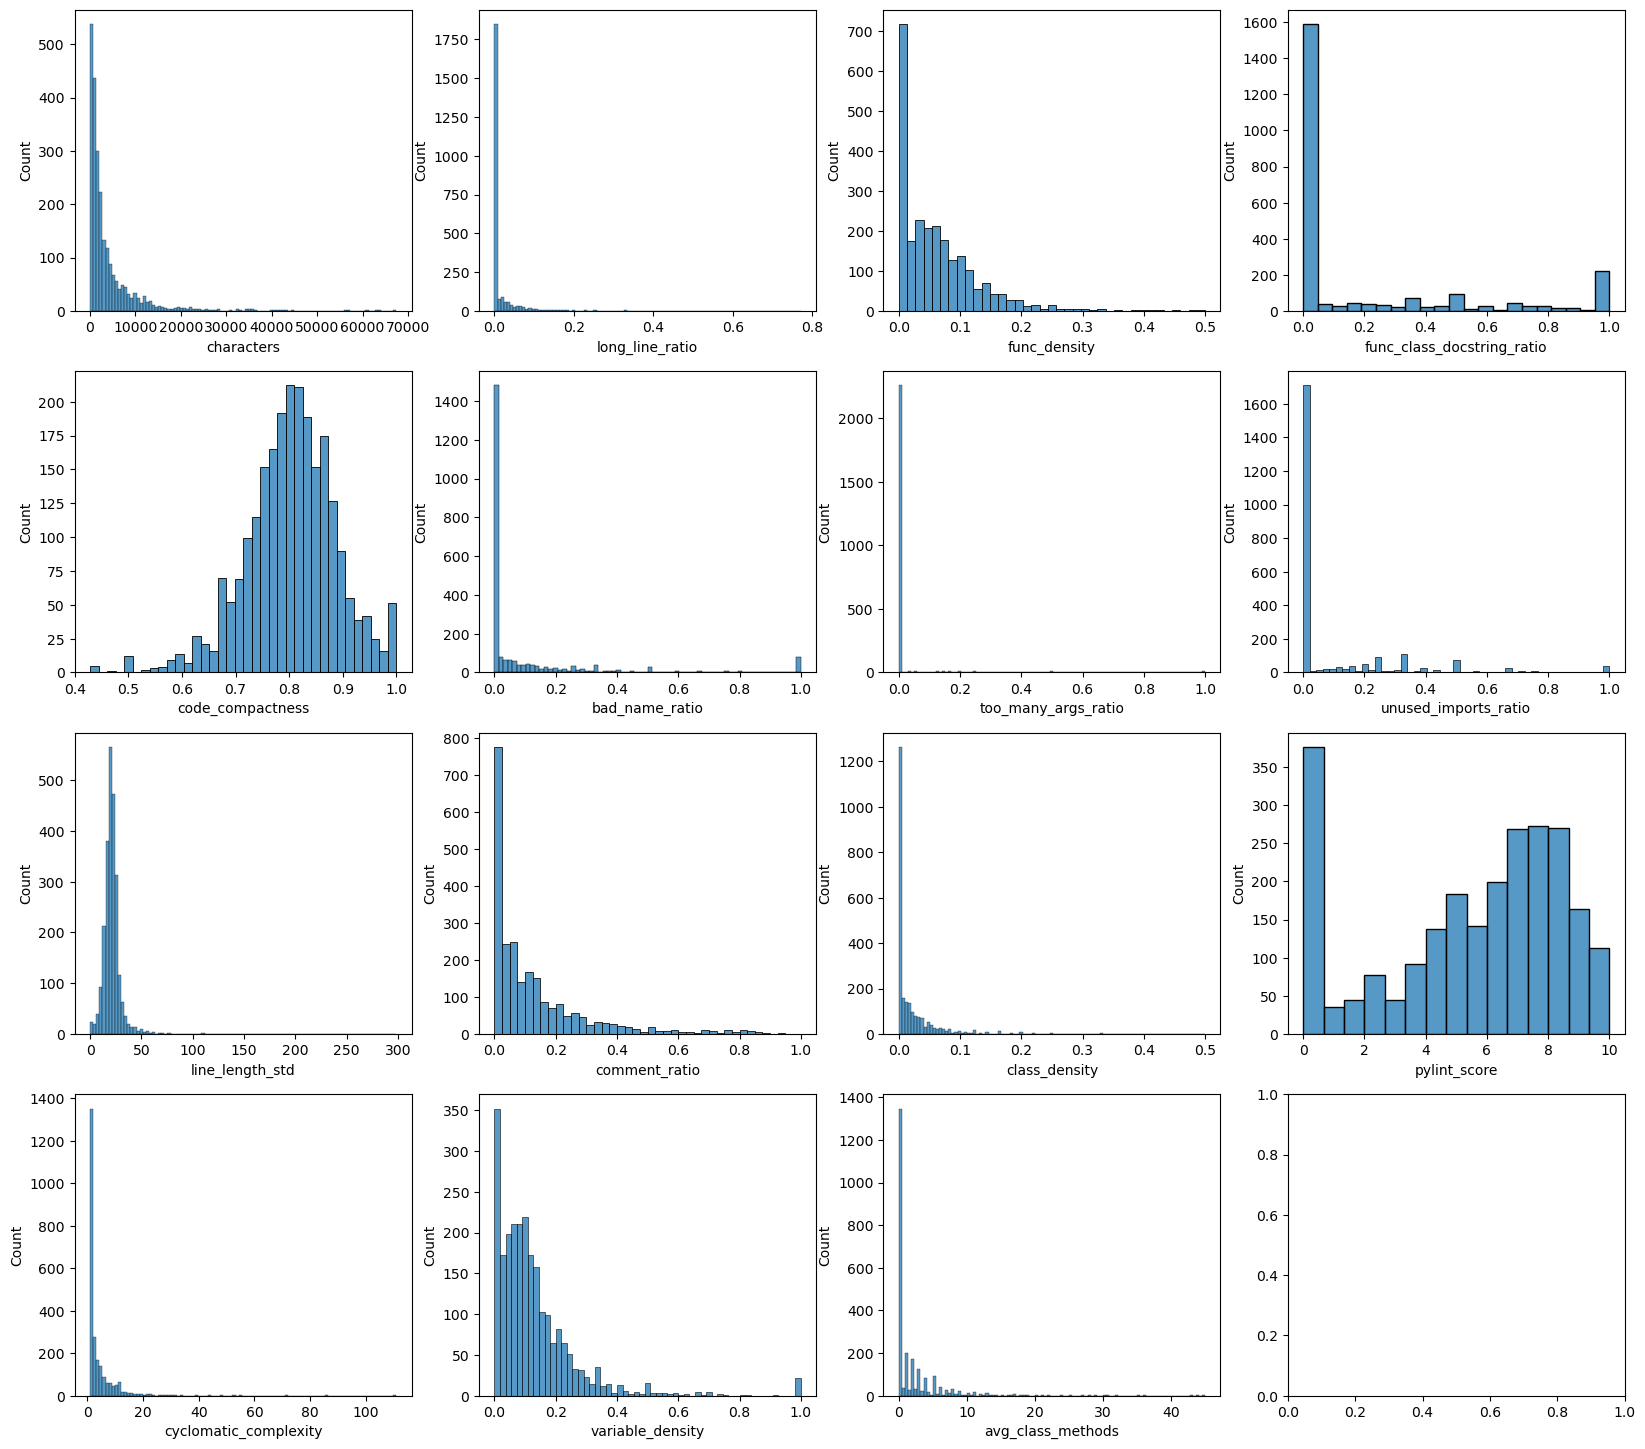

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig , axes = plt.subplots(nrows=4, ncols=4, figsize=(20,18))
for i , feature in enumerate(num_features):
    sns.histplot(data=train, x=feature, ax=axes[i%4, i//4])
plt.show()

We will apply log transform on skewed features that spans a wide range of values

In [6]:
import numpy as np

log_features = [
    "characters",
    "line_length_std",
    "cyclomatic_complexity"
]

train.loc[:, log_features] = np.log1p(train[log_features])

We will not log transform features with scale like any ratio feature (0-1) or the target variable (0-10) because it destroys the variance. Instead we will replace them by a binary feature to detect if the feature is larger than zero or not.

In [7]:
binary_features = [
    "long_line_ratio",
    "bad_name_ratio",
    "too_many_args_ratio",
    "unused_imports_ratio"
]

train.loc[:, binary_features] = (train[binary_features] > 0).astype(int)

Features after transformation

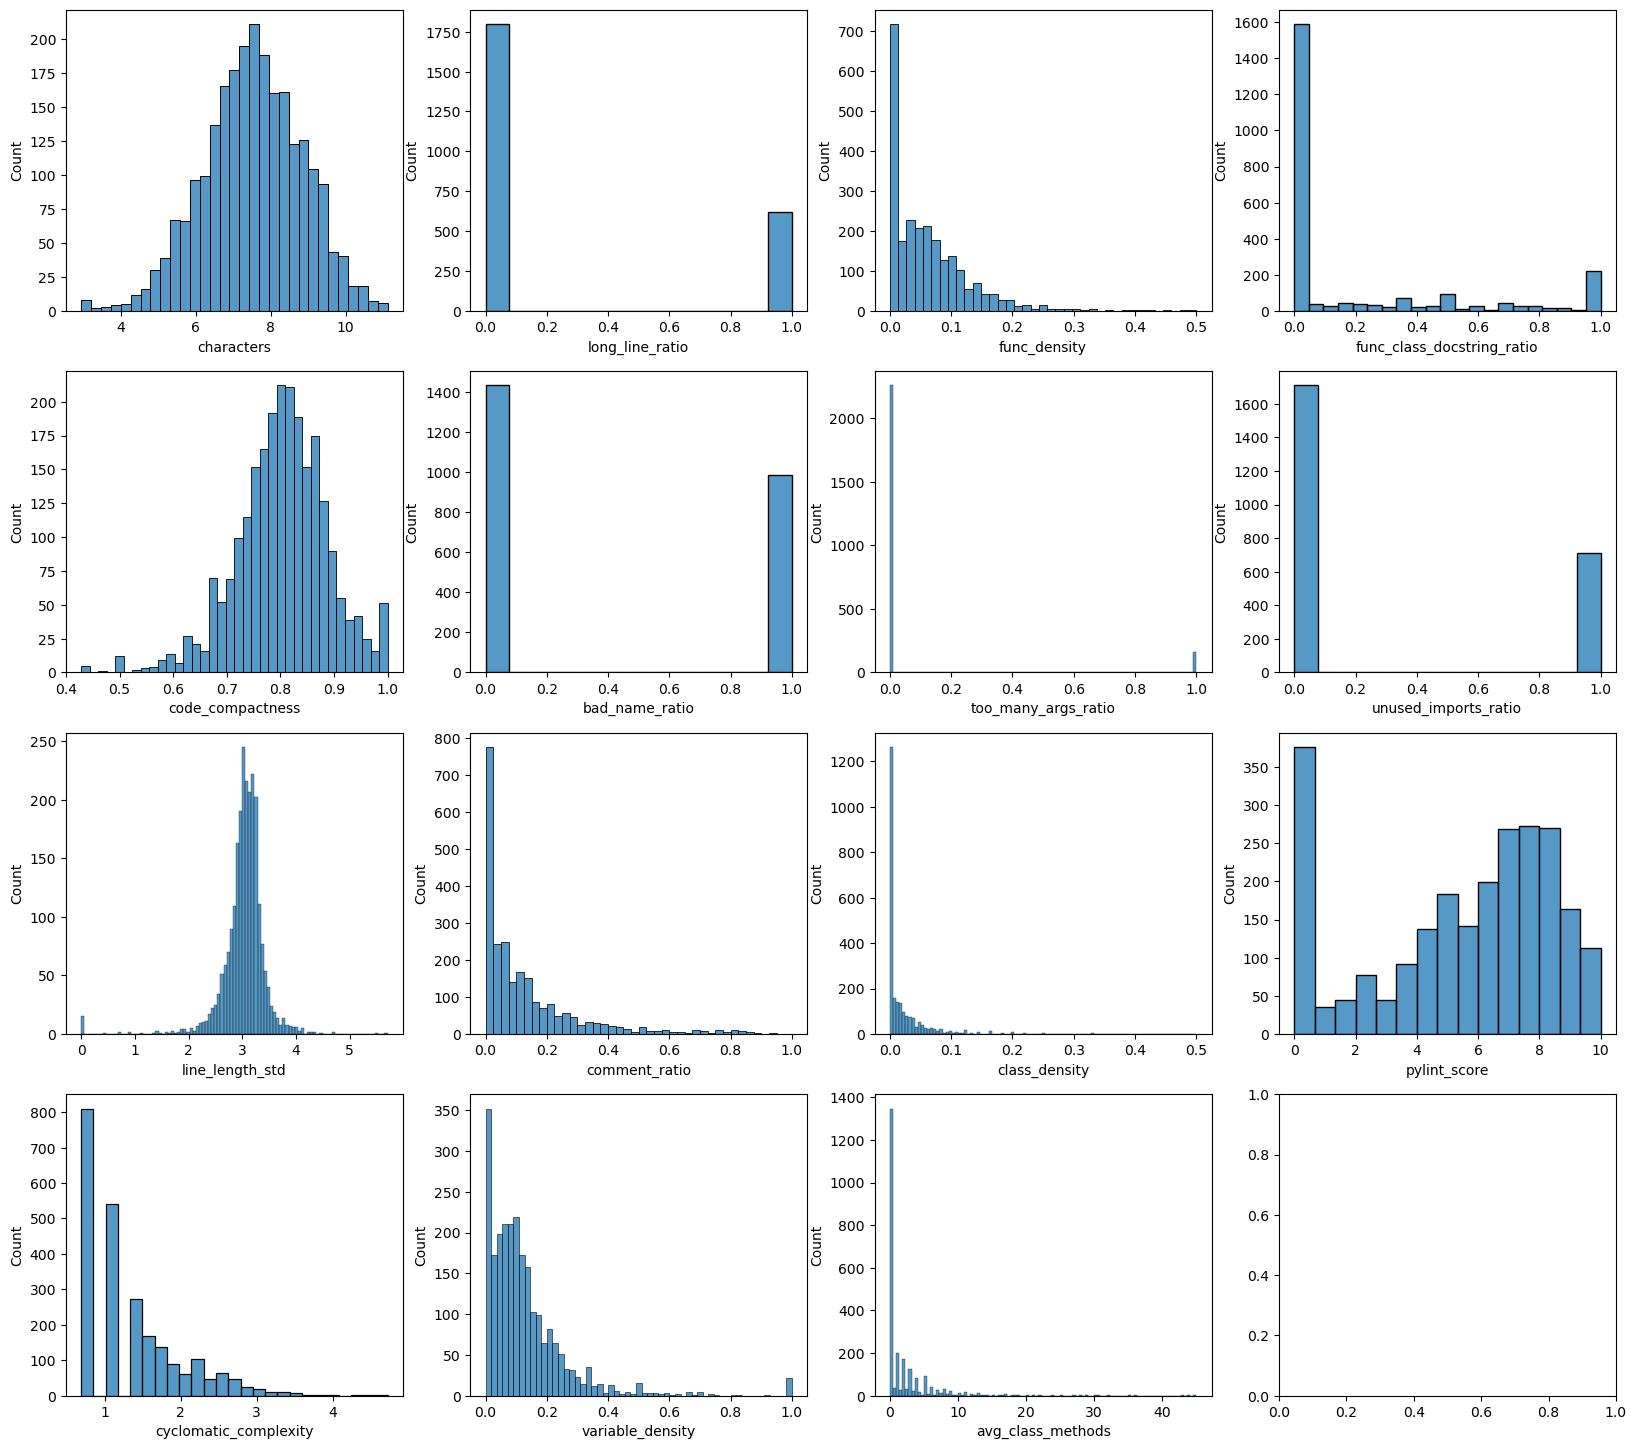

In [8]:
fig , axes = plt.subplots(nrows=4, ncols=4, figsize=(20,18))
for i , feature in enumerate(num_features):
    sns.histplot(data=train, x=feature, ax=axes[i%4, i//4])
plt.show()

We see no strong correlation between numerical features

<Axes: >

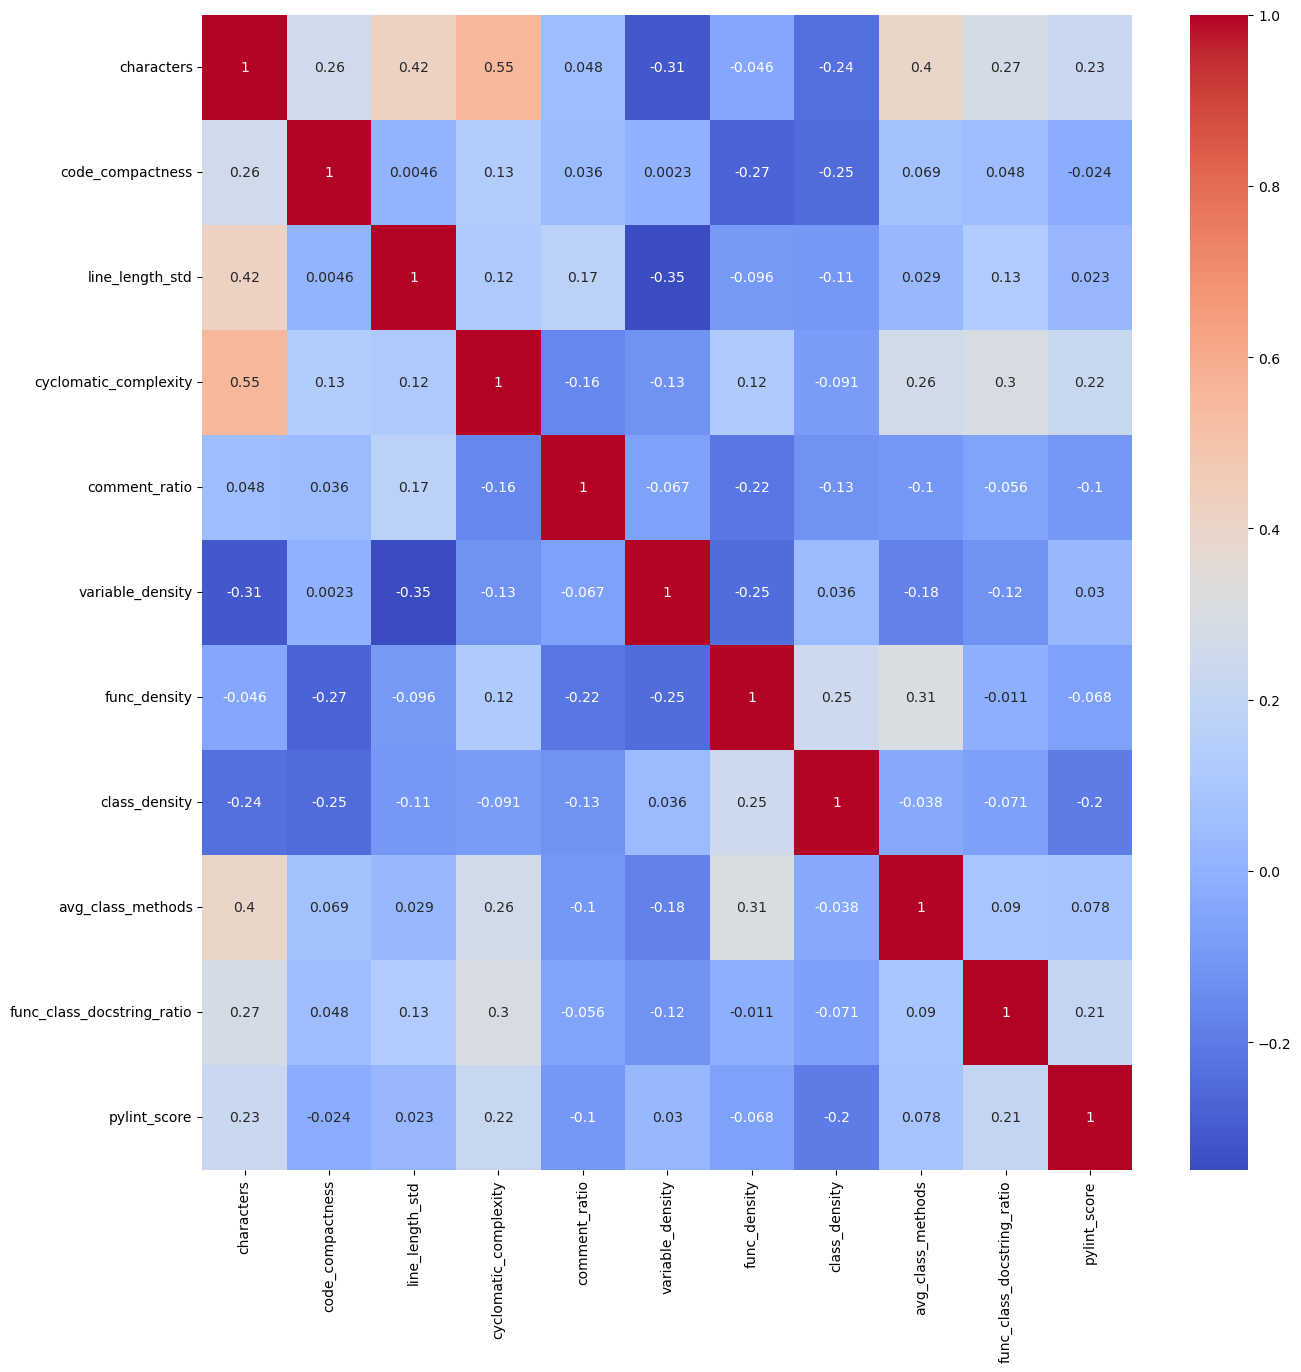

In [9]:
for feat in binary_features:
    num_features.remove(feat)

corr_data = train[num_features].corr(method='pearson')
plt.figure(figsize=(15,15))
sns.heatmap(data= corr_data, cmap='coolwarm', annot=True, fmt='.2g')

Apply changes to df and save it

In [10]:
from python_editor.feature_generation_v2 import generate_transformed_features

features = df.progress_apply(generate_transformed_features, axis=1, result_type="expand")
df_transformed_features = df.join(features)

df_transformed_features.to_pickle("../data/features_v2.pkl")

100%|██████████| 3479/3479 [00:11<00:00, 299.84it/s]
